# 동적 웹페이지 크롤링  : (5) naver news
- https://www.naver.com/

# 라이브러리 불러오기

In [4]:
from datetime import datetime
from pathlib import Path

import pandas as pd

from selenium import webdriver
from selenium.common.exceptions import TimeoutException, NoSuchElementException
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.remote.webelement import WebElement
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import WebDriverWait

# 기본 설정

In [5]:
## URL
TARGET_URL = 'https://www.naver.com/'

## 동적 요소 최대 대기 시간(초)
WAIT_TIMEOUT = 10

## 브라우저 화면 표시 여부
## False : 브라우저 화면 표시
## True : 브라우저 화면을 표시하지 않고 실행
HEADLESS = False

## csv 저장 폴더
PROJECT_DIR = Path.cwd().resolve().parents[1]
OUTPUT_DIR = PROJECT_DIR / 'data' / 'dynamic' / 'naver'

In [6]:
## 디렉토리 생성
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Chrome WebDriver 생성

In [7]:
def create_driver(headless: bool = HEADLESS) -> webdriver.Chrome:
    """
    Chrome WebDriver를 생성하여 반환한다.

    Args:
        headless:
            True이면 브라우저 화면을 표시하지 않고 실행한다.

    Returns:
        Chrome WebDriver 객체    
    """
    options = Options()

    if headless:
        options.add_argument('--headless=new')

    ## 창 최대화 옵션 추가
    options.add_argument('--start-maximized')

    return webdriver.Chrome(options=options)

In [8]:
driver = create_driver()

In [9]:
driver.get(TARGET_URL)

In [11]:
wait = WebDriverWait(driver, WAIT_TIMEOUT)

In [12]:
## 검색창 엘리먼트가 생성될 때까지 대기
wait.until(
    EC.presence_of_element_located((By.ID, 'query'))
)

<selenium.webdriver.remote.webelement.WebElement (session="f214215a50ff6a3a7e3627979d2642f2", element="f.AB6E020FE1183CF1CC5A334C88831FF9.d.D90A1CFB7C1C153EA4A4D050685B951D.e.4")>

In [13]:
print(f'페이지 제목 : {driver.title}')
print(f'현재 url : {driver.current_url}')

페이지 제목 : NAVER
현재 url : https://www.naver.com/


In [14]:
query = driver.find_element(By.ID, 'query')
query

<selenium.webdriver.remote.webelement.WebElement (session="f214215a50ff6a3a7e3627979d2642f2", element="f.AB6E020FE1183CF1CC5A334C88831FF9.d.D90A1CFB7C1C153EA4A4D050685B951D.e.4")>

# 검색어 입력

In [15]:
## 검색어 입력
SEARCH_KEYWORD = 'AI'

## 검색어 입력
query.send_keys(SEARCH_KEYWORD)

In [16]:
from selenium.webdriver.common.keys import Keys

query.send_keys(Keys.ENTER)

# 3번째 뉴스탭 엘리먼트 지정

In [18]:
## 3번째 뉴스탭 지정
third_tab = driver.find_element(By.XPATH, '//*[@id="lnb"]/div[1]/div/div[1]/div[3]/a')

third_tab.get_attribute('outerHTML')

'<a role="tab" href="?ssc=tab.news.all&amp;where=news&amp;sm=tab_jum&amp;query=AI" onclick="return goOtherCR(this,\'a=tab*n.jmp&amp;r=3&amp;i=&amp;u=\'+urlencode(this.href));" class="tab" aria-selected="false">뉴스</a>'

```html
<div class="tab_menu"><a role="tab" href="?ssc=tab.news.all&amp;where=news&amp;sm=tab_jum&amp;query=AI" onclick="return goOtherCR(this,'a=tab*n.jmp&amp;r=3&amp;i=&amp;u='+urlencode(this.href));" class="tab" aria-selected="false">뉴스</a></div>
```

```html
<div class="tab_menu"><a role="tab" href="?ssc=tab.news.all&amp;where=news&amp;sm=tab_jum&amp;query=AI" onclick="return goOtherCR(this,'a=tab*n.jmp&amp;r=3&amp;i=&amp;u='+urlencode(this.href));" class="tab" aria-selected="false">뉴스</a></div>
```

```plaintext
#lnb > div.lnb_group > div > div.lnb_nav_area._nav_area_root > div:nth-child(3)
```

```plaintext
//*[@id="lnb"]/div[1]/div/div[1]/div[3]
```

In [19]:
third_tab.click()

# 현재 페이지 기사 제목들 추출

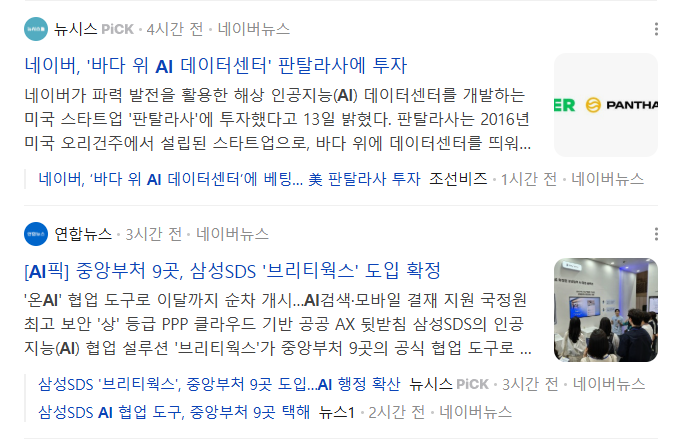

In [20]:
## 기사 제목들만 추출
title_elements = driver.find_elements(By.CSS_SELECTOR, 'span.sds-comps-text-type-headline1')
len(title_elements)

10

## 첫 번째 기사 제목

In [21]:
title_elements[0].get_attribute('outerHTML')

'<span class="sds-comps-text sds-comps-text-ellipsis sds-comps-text-ellipsis-1 sds-comps-text-type-headline1">네이버, \'바다 위 <mark>AI</mark> 데이터센터\' 판탈라사에 투자</span>'

In [72]:
title_elements[0].text

"네이버, '바다 위 AI 데이터센터' 판탈라사에 투자"

## 기사 제목들 추출

In [25]:
for idx, title_element in enumerate(title_elements, 1):
    print(f'{idx}. {title_element.text}')

1. 네이버, '바다 위 AI 데이터센터' 판탈라사에 투자
2. [AI픽] 중앙부처 9곳, 삼성SDS '브리티웍스' 도입 확정
3. 이 대통령 "AI시대 이후 먹거리 준비…7대 첨단기술, 차세대 성장엔진"
4. “말만 공급망 AX 전환”?…협력사 디지털 문맹에 막힌 대기업들의 상...
5. 예약·룸서비스·결제까지 자동화…야놀자, 호텔용 AI 에이전트 출시
6. '올트먼 오픈AI CEO 오늘 사망' ... 어떻게 된 일?
7. 에스트라, KDD 2026서 AI 피부진단 고도화 성과 공개
8. 머스크 "스페이스X AI 매출, 내달 기존 사업 모두 넘어설 것"
9. 구글 '픽셀11 프로 폴드' 출격…삼성·애플과 폴더블 AI폰 격돌
10. "연간 52억 비용 아꼈다"…현대차 공장에 도입된 'AI 기술' 정체


## (연습) XPATH

### 기본 경로 기호 

| 기호 | 의미 | 폴더 비유 | 예시 | 설명 |
| :--- | :--- | :--- | :--- | :--- |
| **`/`** | 루트(직계 자식) | 바로 아래 폴더 | `/html/body` | `html` 바로 밑의 `body` |
| **`//`** | 전체(모든 후손) | 하위 모든 폴더 검색 | `//a` | 위치 상관없이 모든 `<a>` 태그 |
| **`.`** | 현재 위치 | 현재 폴더 | `./div` | 현재 위치 바로 아래 `div` |
| **`..`** | 상위 위치 | 부모 폴더 | `../` | 현재 요소의 부모 요소 |
| **`@`** | 속성(Attribute) | 파일의 속성 | `//@href` | 모든 `href` 속성 값 |


### naver 뉴스 : 경제

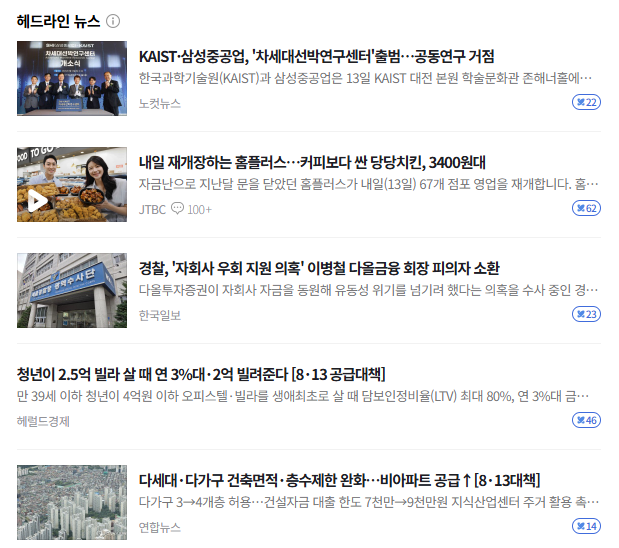

In [26]:
driver

<selenium.webdriver.chrome.webdriver.WebDriver (session="f214215a50ff6a3a7e3627979d2642f2")>

In [27]:
xpath_driver = create_driver()
xpath_driver

<selenium.webdriver.chrome.webdriver.WebDriver (session="aca157654246c7c52341680a7ad898ea")>

In [28]:
url_naver_news = 'https://news.naver.com/section/101'
xpath_driver.get(url_naver_news)

In [29]:
wait = WebDriverWait(xpath_driver, WAIT_TIMEOUT)

In [58]:
news_card = xpath_driver.find_element(By.CSS_SELECTOR, 'ul.sa_list')
news_card

<selenium.webdriver.remote.webelement.WebElement (session="aca157654246c7c52341680a7ad898ea", element="f.E6EA2F136F08F81568B3A6625CC1CF9E.d.60346561D003C90EF8C4142EE3A4A612.e.5450")>

In [59]:
news_card.get_attribute('outerHTML')

'<ul id="_SECTION_HEADLINE_LIST_n1ukz" class="sa_list">\n\t\t<li class="sa_item _SECTION_HEADLINE">\n\t\t\t<div class="sa_item_inner">\n\t\t\t\t<div class="sa_item_flex _LAZY_LOADING_WRAP">\n\t\t\t\t\t<div class="sa_thumb _LAZY_LOADING_ERROR_HIDE">\n\t\t\t\t\t\t<div class="sa_thumb_inner">\n\t\t\t\t\t\t\t<a href="https://n.news.naver.com/mnews/article/052/0002392789" class="sa_thumb_link _NLOG_IMPRESSION" tabindex="-1" aria-hidden="true" data-clk="eco.clart" data-nlog-area="content.headline.article" data-nlog-params="{&quot;section1_id&quot;:&quot;101&quot;,&quot;rank&quot;:1}" data-imp-gdid="880000AF_000000000000000002392789" data-imp-url="https://n.news.naver.com/mnews/article/052/0002392789" data-imp-index="1">\n\t\t\t\t\t\t\t\t<img class="_LAZY_LOADING _LAZY_LOADING_INIT_HIDE" width="110" height="75" alt="" style="" src="https://mimgnews.pstatic.net/image/origin/052/2026/08/13/2392789.jpg?type=nf220_150">\n\t\t\t\t\t\t\t\t<span class="sa_thumb_play">\n\t\t\t\t\t\t\t\t\t<em class="b

'<body class="n_news_mnews fs1 as_mp_layout as_section_home">\n\t\t<div class="end_container">\n\t\t<div class="u_skip"><a href="#ct">본문 바로가기</a></div>\n\t\t<header role="banner" class="as_gnb_mnews as_type_section">\n\t<div class="header_inner">\n\t\t<div class="Ngnb">\n\t\t\t<div class="Ngnb_inner">\n\t\t\t\t<div class="Ngnb_both">\n\t\t\t\t\t<div class="Ngnb_left">\n\t\t\t\t\t\t<span class="Ngnb_logo"><a href="https://m.naver.com/" class="Nlogo_link _LINK" data-clk="gnb.naver" data-nlog-area="gnb.naver" data-url="https://m.naver.com/" data-pc-url="https://www.naver.com/"><span class="Nicon_logo">NAVER</span></a></span>\n\t\t\t\t\t\t<div class="Ngnb_service">\n\t\t\t\t\t\t\t<h1 class="Nservice_item"><a href="https://m.news.naver.com" class="_LINK" data-clk="gnb.news" data-nlog-area="gnb.news" data-url="https://m.news.naver.com" data-pc-url="https://news.naver.com/"><span class="Nicon_service">뉴스</span></a></h1>\n\t\t\t\t\t\t\t<span class="Nservice_subitem">\n\t\t\t\t\t\t\t\t<a href="
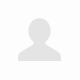
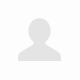

In [60]:
xpath_root = news_card.find_element(By.XPATH, '/html/body')
xpath_root.get_attribute('outerHTML')

'<body class="wrap-new api_animation tabsch tabsch_news" data-slog-p="jF1v0wqps2wssB6cknN-355207" data-slog-pn="1" data-slog-url="https://l.search.naver.com/n/scrolllog/pc/v2?u=https%3A%2F%2Fsearch.naver.com%2Fsearch.naver%3Fssc%3Dtab.news.all%26where%3Dnews%26sm%3Dtab_jum%26query%3DAI&amp;q=AI&amp;sscode=tab.news.all&amp;pg=jF1v0wqps2wssB6cknN-355207" data-slog-visible="true"> <div id="nxtt_div" style="display:none;position:absolute;border-width:0;z-index:11000"></div><script>try{performance.mark(\'nx-body-start\')}catch(e){}</script><div id="u_skip"> <a href="#lnb"><span>메뉴 영역으로 바로가기</span></a> <a href="#content"><span>본문 영역으로 바로가기</span></a> </div><div id="wrap"><div id="header_wrap" class="type_fixed"> <div class="api_floating_header spi-lnb">  <div class="gnb_wrap"> <div class="header_group"> <div class="search_area"> <h1 class="logo"><a href="https://www.naver.com" onclick="return goOtherCR(this, \'a=sta.naver&amp;r=&amp;i=&amp;u=\'+urlencode(this.href));" class="link"><i class="
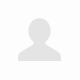
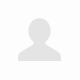

In [61]:
xpath_root_2 = driver.find_element(By.XPATH, '/html/body')
xpath_root_2.get_attribute('outerHTML')

In [62]:
xpath_first_li = driver.find_element(By.XPATH, '//li')
xpath_first_li.get_attribute('outerHTML')

'<li class="gnb_login_li" id="gnb_login_layer" style="display: inline-block;"><a class="gnb_btn_login" href="https://nid.naver.com/nidlogin.login?url=https%3A%2F%2Fsearch.naver.com%2Fsearch.naver%3Fssc%3Dtab.news.all%26where%3Dnews%26sm%3Dtab_jum%26query%3DAI" id="gnb_login_button"><span class="gnb_bg"></span><span class="gnb_bdr"></span><span class="gnb_txt">로그인</span></a></li>'

In [63]:
xpath_current_first_li = news_card.find_element(By.XPATH, './/li')
xpath_current_first_li.get_attribute('outerHTML')

'<li class="sa_item _SECTION_HEADLINE">\n\t\t\t<div class="sa_item_inner">\n\t\t\t\t<div class="sa_item_flex _LAZY_LOADING_WRAP">\n\t\t\t\t\t<div class="sa_thumb _LAZY_LOADING_ERROR_HIDE">\n\t\t\t\t\t\t<div class="sa_thumb_inner">\n\t\t\t\t\t\t\t<a href="https://n.news.naver.com/mnews/article/052/0002392789" class="sa_thumb_link _NLOG_IMPRESSION" tabindex="-1" aria-hidden="true" data-clk="eco.clart" data-nlog-area="content.headline.article" data-nlog-params="{&quot;section1_id&quot;:&quot;101&quot;,&quot;rank&quot;:1}" data-imp-gdid="880000AF_000000000000000002392789" data-imp-url="https://n.news.naver.com/mnews/article/052/0002392789" data-imp-index="1">\n\t\t\t\t\t\t\t\t<img class="_LAZY_LOADING _LAZY_LOADING_INIT_HIDE" width="110" height="75" alt="" style="" src="https://mimgnews.pstatic.net/image/origin/052/2026/08/13/2392789.jpg?type=nf220_150">\n\t\t\t\t\t\t\t\t<span class="sa_thumb_play">\n\t\t\t\t\t\t\t\t\t<em class="blind">동영상뉴스</em>\n\t\t\t\t\t\t\t\t</span>\n\t\t\t\t\t\t\t</a

In [64]:
## 현재 위치를 기준으로 모든 속성 href의 값
xpath_current_all_href = news_card.find_elements(By.XPATH, './/*[@class="sa_text_strong"]')
xpath_current_all_href[0].get_attribute('outerHTML')

'<strong class="sa_text_strong">정부, 수도권 주택 추가 공급...금융지원도 강화</strong>'

In [65]:
len(xpath_current_all_href)

10

In [66]:
xpath_current_all_href[0].text

'정부, 수도권 주택 추가 공급...금융지원도 강화'

In [67]:
for xpath_element in xpath_current_all_href:
    print(xpath_element.text)

정부, 수도권 주택 추가 공급...금융지원도 강화
임대사업자 주담대 푼다…신축 빌라 LTV 최대 60%[8·13 부동산대책]
"월세 대신 빌라사라"…'4억 이하 비아파트' 청년 주담대 신설 [8·13 부동산대책]
고려아연 이차전지 소재 자회사, 글로벌 배터리사에 동박 첫 공급
대출 오픈런 해소?…이주비·중도금·잔금대출 문 넓어진다 [8·13 대책]







In [69]:
xpath_driver.quit()
print('연습용 브라우저 종료')

연습용 브라우저 종료


## 뉴스 카드 단위로 추출

In [75]:
title_elements[0].text

"네이버, '바다 위 AI 데이터센터' 판탈라사에 투자"

In [87]:
news_card = title_elements[0].find_element(By.XPATH, './ancestor::div[.//*[@data-sds-comp="Profile"]][1]')
news_card.get_attribute('outerHTML')

'<div class="sds-comps-vertical-layout sds-comps-full-layout HdcGo47Jt3sGLkT5"><div class="sds-comps-horizontal-layout sds-comps-full-layout sds-comps-profile type-basic size-lg title-color-g10 b5_jBbh3nEAGB3WT" data-sds-comp="Profile"><div class="sds-comps-horizontal-layout sds-comps-inline-layout sds-comps-profile-source"><div class="sds-comps-horizontal-layout sds-comps-inline-layout sds-comps-profile-source-thumb"><a nocr="1" href="https://media.naver.com/press/003" class="fender-ui_228e3bd1" target="_blank" data-heatmap-target=".prof"><div class="sds-comps-horizontal-layout sds-comps-inline-layout sds-comps-profile-thumbnail type-basic size-lg" data-sds-comp="ProfileThumbnail"><div class="sds-comps-base-layout sds-comps-inline-layout sds-comps-image sds-comps-image-circle fit-cover" style="width:24px;height:24px;aspect-ratio:1/1" data-sds-comp="RectangleImage" data-dimmed="3%"><img width="24" height="24" alt="뉴시스의 프로필 이미지" loading="lazy" src="https://search.pstatic.net/common/?src

## 언론사

In [88]:
press_element = news_card.find_element(By.CSS_SELECTOR, 'a[href*="media.naver.com/press/"] span.sds-comps-text')
press_element.get_attribute('outerHTML')

'<span class="sds-comps-text sds-comps-text-ellipsis sds-comps-text-ellipsis-1 sds-comps-text-type-body2 sds-comps-text-weight-sm">뉴시스</span>'

In [90]:
press = press_element.text
press

'뉴시스'

## 요약

In [92]:
summary_element = news_card.find_element(By.CSS_SELECTOR, 'a[data-heatmap-target=".body"]')
summary_element.get_attribute('outerHTML')

'<a nocr="1" href="https://www.newsis.com/view/NISX20260813_0003747235" class="fender-ui_228e3bd1 sIRTVUHyqQMUzFPH" target="_blank" data-heatmap-target=".body"><span class="sds-comps-text sds-comps-text-ellipsis sds-comps-text-ellipsis-3 sds-comps-text-type-body1">네이버가 파력 발전을 활용한 해상 인공지능(<mark>AI</mark>) 데이터센터를 개발하는 미국 스타트업 \'판탈라사\'에 투자했다고 13일 밝혔다. 판탈라사는 2016년 미국 오리건주에서 설립된 스타트업으로, 바다 위에 데이터센터를 띄워 파도가 움직이는 힘으로 전력을 생산하고 <mark>AI</mark> 연산까지 수행하는 부유식 <mark>AI</mark> 데이터센터를... </span><span class="fender-ui_0cb57fb2">새 창 열림</span></a>'

In [98]:
summary = summary_element.text.splitlines()[0]
summary

"네이버가 파력 발전을 활용한 해상 인공지능(AI) 데이터센터를 개발하는 미국 스타트업 '판탈라사'에 투자했다고 13일 밝혔다. 판탈라사는 2016년 미국 오리건주에서 설립된 스타트업으로, 바다 위에 데이터센터를 띄워 파도가 움직이는 힘으로 전력을 생산하고 연산까지 수행하는 부유식 데이터센터를..."

## 이미지

### 이미지 엘리먼트

In [105]:
img_element = news_card.find_element(By.CSS_SELECTOR, 'a[data-heatmap-target=".img"] img')
img_element.get_attribute('outerHTML')

'<img width="104" alt="네이버, \'바다 위 &lt;mark&gt;AI&lt;/mark&gt; 데이터센터\' 판탈라사에 투자의 이미지" loading="lazy" src="https://search.pstatic.net/common/?src=https%3A%2F%2Fimgnews.pstatic.net%2Fimage%2Forigin%2F003%2F2026%2F08%2F13%2F14124556.jpg&amp;type=fface200_200&amp;expire=2&amp;refresh=true">'

### 이미지 url

In [106]:
img_url = img_element.get_attribute('src')
img_url

'https://search.pstatic.net/common/?src=https%3A%2F%2Fimgnews.pstatic.net%2Fimage%2Forigin%2F003%2F2026%2F08%2F13%2F14124556.jpg&type=fface200_200&expire=2&refresh=true'

In [107]:
img_url = img_element.get_attribute('currentSrc')
img_url

'https://search.pstatic.net/common/?src=https%3A%2F%2Fimgnews.pstatic.net%2Fimage%2Forigin%2F003%2F2026%2F08%2F13%2F14124556.jpg&type=fface200_200&expire=2&refresh=true'

### 이미지 다운로드

In [108]:
## 이미지 저장 경로
IMAGE_DIR = PROJECT_DIR / 'data' / 'dynamic' / 'naver' / SEARCH_KEYWORD / 'images'
IMAGE_DIR

WindowsPath('D:/AI/data_analytics/crawling/01-data-collection-pipeline/data/dynamic/naver/AI/images')

In [109]:
## 디렉토리 생성
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

In [110]:
import requests

## 이미지 요청
response = requests.get(img_url, timeout=(10, 30))

## HTTP 오류 확인
response.raise_for_status()

response.status_code

200

In [112]:
## 이미지 파일 경로
image_file = IMAGE_DIR / 'news_001.jpg'
image_file

WindowsPath('D:/AI/data_analytics/crawling/01-data-collection-pipeline/data/dynamic/naver/AI/images/news_001.jpg')

In [113]:
## 이미지 저장
image_file.write_bytes(response.content)

print(f'이미지 저장 완료 : {image_file}')

이미지 저장 완료 : D:\AI\data_analytics\crawling\01-data-collection-pipeline\data\dynamic\naver\AI\images\news_001.jpg
